## Imports

In [1]:
!pip install shap


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

print(f"SHAP version : {shap.__version__}")
print("All imports done!")

SHAP version : 0.52.0
All imports done!


## Load model, scaler, feature names

In [9]:
# ── Load everything saved from XGBoost notebook ───────────
model  = joblib.load('models/xgboost_model.pkl')
scaler = joblib.load('models/scaler.pkl')

print(f"XGBoost model loaded!")
print(f"Model type      : {type(model)}")
print(f"Model n_features: {model.n_features_in_}")

# ── Get exact feature names model was trained on ──────────
# model.feature_names_in_ contains the EXACT columns
# XGBoost was trained with — this is the ground truth

if hasattr(model, 'feature_names_in_') and model.feature_names_in_ is not None:
    FEATURE_COLS = list(model.feature_names_in_)
    print(f"\nFeature names from model: {len(FEATURE_COLS)}")
else:
    # Fallback — load from saved file if exists
    try:
        FEATURE_COLS = joblib.load('models/feature_names.pkl')
        print(f"\nFeature names from pkl: {len(FEATURE_COLS)}")
    except:
        FEATURE_COLS = None
        print("\nWARNING: Could not get feature names from model")

if FEATURE_COLS:
    print(f"\nFirst 10 features:")
    for i, f in enumerate(FEATURE_COLS[:10], 1):
        print(f"  {i:2}. {f}")
    print(f"  ...")
    print(f"  Total: {len(FEATURE_COLS)} features")

XGBoost model loaded!
Model type      : <class 'xgboost.sklearn.XGBClassifier'>
Model n_features: 30

Feature names from model: 30

First 10 features:
   1. Hour
   2. Day
   3. DayOfWeek
   4. IsWeekend
   5. Sender Bank ID
   6. Receiver Bank ID
   7. is_cross_bank
   8. is_self_transfer
   9. Amount_Paid_Log
  10. Amount_Received_Log
  ...
  Total: 30 features


## Load featured dataset and align features

In [18]:
# ============================================================
# COMPLETE XGBOOST FEATURE PREPARATION
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# 1. LOAD FEATURED DATASET
# ============================================================

FEATURED_PATH = "featured/featured_transactions.csv"
RAW_PATH = "cleaned_transactions.csv"

print("=" * 70)
print("LOADING DATA")
print("=" * 70)

df_feat = pd.read_csv(FEATURED_PATH)

print(
    f"Featured dataset shape : {df_feat.shape}"
)

print(
    f"Featured columns       : {len(df_feat.columns)}"
)


# ============================================================
# 2. TARGET
# ============================================================

TARGET_COL = "Is Laundering"

if TARGET_COL not in df_feat.columns:

    raise KeyError(
        f"Target column '{TARGET_COL}' "
        "is not present in featured dataset."
    )

y_all = df_feat[TARGET_COL]


# ============================================================
# 3. EXACT FEATURES EXPECTED BY YOUR XGBOOST MODEL
# ============================================================

FEATURE_COLS = [
    "Hour",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Sender Bank ID",
    "Receiver Bank ID",
    "is_cross_bank",
    "is_self_transfer",
    "Amount_Paid_Log",
    "Amount_Received_Log",
    "Amount_Diff_Log",
    "amount_vs_account_median",
    "Payment_Currency_Encoded",
    "Receiving_Currency_Encoded",
    "is_currency_mismatch",
    "is_amount_outlier_iqr",
    "is_amount_outlier_zscore",
    "is_account_level_outlier",
    "outlier_score",
    "is_outlier",
    "txn_count_per_sender_hour",
    "txn_count_per_sender_day",
    "is_high_velocity",
    "fmt_ACH",
    "fmt_Bitcoin",
    "fmt_Cash",
    "fmt_Cheque",
    "fmt_Credit Card",
    "fmt_Reinvestment",
    "fmt_Wire"
]

print("\n" + "=" * 70)
print("XGBOOST FEATURE LIST")
print("=" * 70)

print(
    f"Expected XGBoost features : {len(FEATURE_COLS)}"
)


# ============================================================
# 4. CHECK WHETHER MISSING FEATURES ALREADY EXIST
# ============================================================

missing_before = [
    col
    for col in FEATURE_COLS
    if col not in df_feat.columns
]

print(
    f"Missing before recovery  : {len(missing_before)}"
)

if missing_before:

    print("\nMissing features:")

    for col in missing_before:
        print("  -", col)


# ============================================================
# 5. LOAD CLEANED/RAW TRANSACTION DATA
# ============================================================

if len(missing_before) > 0:

    if not os.path.exists(RAW_PATH):

        raise FileNotFoundError(
            f"\n'{RAW_PATH}' was not found.\n"
            "The missing Amount Received information "
            "cannot be reconstructed from featured_transactions.csv."
        )

    print("\n" + "=" * 70)
    print("LOADING CLEANED TRANSACTION DATA")
    print("=" * 70)

    df_raw = pd.read_csv(RAW_PATH)

    print(
        f"Raw dataset shape : {df_raw.shape}"
    )

    print(
        f"Raw columns       : {len(df_raw.columns)}"
    )

    print("\nRaw amount-related columns:")

    for col in df_raw.columns:

        if (
            "amount" in col.lower()
            or "received" in col.lower()
            or "paid" in col.lower()
        ):

            print("  ", repr(col))


# ============================================================
# 6. FIND AMOUNT RECEIVED COLUMN
# ============================================================

if "Amount_Received_Log" in missing_before:

    possible_received_cols = [
        "Amount Received",
        "Amount_Received",
        "Amount Received USD",
        "Amount_Received_USD",
        "Received Amount",
        "received_amount",
        "Amount Received (USD)"
    ]

    received_col = None

    for col in possible_received_cols:

        if col in df_raw.columns:

            received_col = col
            break


    # --------------------------------------------------------
    # If exact known names were not found, search automatically
    # --------------------------------------------------------

    if received_col is None:

        received_candidates = [
            col
            for col in df_raw.columns
            if (
                "received" in col.lower()
                and "amount" in col.lower()
            )
        ]

        if len(received_candidates) == 1:

            received_col = received_candidates[0]

        elif len(received_candidates) > 1:

            print(
                "\nMultiple possible Amount Received columns found:"
            )

            for col in received_candidates:
                print("  -", col)

            raise ValueError(
                "More than one possible Amount Received "
                "column was found. Please select the correct "
                "transaction-level amount column."
            )


    if received_col is None:

        raise KeyError(
            "\nCould not find a transaction-level "
            "'Amount Received' column in cleaned_transactions.csv.\n\n"
            "Available raw columns are:\n"
            + "\n".join(
                f"  - {col}"
                for col in df_raw.columns
            )
        )


    print(
        f"\n✓ Amount Received column found: {received_col}"
    )


# ============================================================
# 7. FIND AMOUNT PAID COLUMN
# ============================================================

if "Amount_Diff_Log" in missing_before:

    possible_paid_cols = [
        "Amount Paid",
        "Amount_Paid",
        "Amount Paid USD",
        "Amount_Paid_USD",
        "Paid Amount",
        "paid_amount",
        "Amount Paid (USD)"
    ]

    paid_col = None

    for col in possible_paid_cols:

        if col in df_raw.columns:

            paid_col = col
            break


    if paid_col is None:

        paid_candidates = [
            col
            for col in df_raw.columns
            if (
                "paid" in col.lower()
                and "amount" in col.lower()
            )
        ]

        if len(paid_candidates) == 1:

            paid_col = paid_candidates[0]

        elif len(paid_candidates) > 1:

            print(
                "\nMultiple possible Amount Paid columns found:"
            )

            for col in paid_candidates:
                print("  -", col)

            raise ValueError(
                "More than one possible Amount Paid "
                "column was found."
            )


    if paid_col is None:

        raise KeyError(
            "\nCould not find a transaction-level "
            "'Amount Paid' column in cleaned_transactions.csv."
        )


    print(
        f"✓ Amount Paid column found: {paid_col}"
    )


# ============================================================
# 8. VERIFY ROW ALIGNMENT
# ============================================================

print("\n" + "=" * 70)
print("CHECKING ROW ALIGNMENT")
print("=" * 70)

print(
    "Featured rows:",
    len(df_feat)
)

print(
    "Raw rows     :",
    len(df_raw)
)


if len(df_feat) != len(df_raw):

    raise ValueError(
        "\nThe featured dataset and cleaned dataset "
        "have different numbers of rows.\n\n"
        f"Featured rows = {len(df_feat):,}\n"
        f"Raw rows      = {len(df_raw):,}\n\n"
        "Do NOT directly assign Amount Received by row position. "
        "The datasets need to be matched using a transaction ID "
        "or another unique identifier."
    )


print(
    "✓ Row counts match."
)


# ============================================================
# 9. CREATE AMOUNT_RECEIVED_LOG
# ============================================================

if "Amount_Received_Log" in missing_before:

    received_values = pd.to_numeric(
        df_raw[received_col],
        errors="coerce"
    )

    received_values = received_values.fillna(0)

    received_values = received_values.clip(
        lower=0
    )

    df_feat["Amount_Received_Log"] = np.log1p(
        received_values
    )

    print(
        "\n✓ Created Amount_Received_Log"
    )


# ============================================================
# 10. CREATE AMOUNT_DIFF_LOG
# ============================================================

if "Amount_Diff_Log" in missing_before:

    paid_values = pd.to_numeric(
        df_raw[paid_col],
        errors="coerce"
    )

    received_values = pd.to_numeric(
        df_raw[received_col],
        errors="coerce"
    )

    paid_values = paid_values.fillna(0)
    received_values = received_values.fillna(0)

    amount_difference = (
        paid_values - received_values
    ).abs()

    df_feat["Amount_Diff_Log"] = np.log1p(
        amount_difference
    )

    print(
        "✓ Created Amount_Diff_Log"
    )


# ============================================================
# 11. FINAL FEATURE VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE VALIDATION")
print("=" * 70)

missing_after = [
    col
    for col in FEATURE_COLS
    if col not in df_feat.columns
]


print(
    f"Expected features : {len(FEATURE_COLS)}"
)

print(
    f"Available features: "
    f"{len(FEATURE_COLS) - len(missing_after)}"
)

print(
    f"Missing features  : {len(missing_after)}"
)


if missing_after:

    print("\n❌ STILL MISSING:")

    for col in missing_after:
        print("  -", col)

    raise ValueError(
        "\nXGBoost feature preparation failed.\n"
        "The model still has missing input features."
    )


print(
    "\n✓ ALL 30 XGBOOST FEATURES ARE AVAILABLE"
)


# ============================================================
# 12. SELECT FEATURES IN EXACT MODEL ORDER
# ============================================================

X_all = df_feat[
    FEATURE_COLS
].copy()


# ============================================================
# 13. CLEAN NUMERIC VALUES
# ============================================================

X_all = X_all.replace(
    [np.inf, -np.inf],
    np.nan
)

X_all = X_all.fillna(0)


# ============================================================
# 14. FORCE NUMERIC DATA
# ============================================================

for col in X_all.columns:

    X_all[col] = pd.to_numeric(
        X_all[col],
        errors="coerce"
    )


X_all = X_all.fillna(0)


# ============================================================
# 15. FINAL SHAPE CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL XGBOOST INPUT")
print("=" * 70)

print(
    f"X_all shape : {X_all.shape}"
)

print(
    f"y_all shape : {y_all.shape}"
)

print(
    f"Number of features : {X_all.shape[1]}"
)

print(
    f"Fraud rows : {int(y_all.sum()):,}"
)

print(
    f"Normal rows: {int((y_all == 0).sum()):,}"
)


# ============================================================
# 16. VERIFY FEATURE ORDER
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE ORDER")
print("=" * 70)

for i, col in enumerate(X_all.columns):

    print(
        f"{i:2d}. {col}"
    )


# ============================================================
# 17. FINAL ASSERTIONS
# ============================================================

assert X_all.shape[1] == len(FEATURE_COLS)

assert list(X_all.columns) == FEATURE_COLS

assert len(X_all) == len(y_all)


print("\n" + "=" * 70)
print("SUCCESS")
print("=" * 70)

print(
    "✓ XGBoost feature count matches"
)

print(
    "✓ XGBoost feature order matches"
)

print(
    "✓ No required features are missing"
)

print(
    "✓ NaN/Inf values handled"
)

print(
    "✓ X_all is ready for XGBoost / SHAP"
)

LOADING DATA
Featured dataset shape : (5078336, 80)
Featured columns       : 80

XGBOOST FEATURE LIST
Expected XGBoost features : 30
Missing before recovery  : 2

Missing features:
  - Amount_Received_Log
  - Amount_Diff_Log

LOADING CLEANED TRANSACTION DATA
Raw dataset shape : (5078336, 32)
Raw columns       : 32

Raw amount-related columns:
   'Amount Paid'
   'Amount Received'
   'amount_vs_account_median'
   'is_amount_outlier_iqr'
   'is_amount_outlier_zscore'

✓ Amount Received column found: Amount Received
✓ Amount Paid column found: Amount Paid

CHECKING ROW ALIGNMENT
Featured rows: 5078336
Raw rows     : 5078336
✓ Row counts match.

✓ Created Amount_Received_Log
✓ Created Amount_Diff_Log

FINAL FEATURE VALIDATION
Expected features : 30
Available features: 30
Missing features  : 0

✓ ALL 30 XGBOOST FEATURES ARE AVAILABLE

FINAL XGBOOST INPUT
X_all shape : (5078336, 30)
y_all shape : (5078336,)
Number of features : 30
Fraud rows : 5,177
Normal rows: 5,073,159

FINAL FEATURE ORDE

## Recreate train/test split (same as XGBoost notebook)

In [21]:
print("SCALER FEATURES:")
print(list(scaler.feature_names_in_))

print("\nXGBOOST FEATURES:")
print(FEATURE_COLS)

print("\nScaler feature count:")
print(scaler.n_features_in_)

print("\nXGBoost feature count:")
print(len(FEATURE_COLS))

SCALER FEATURES:
['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID', 'Receiver Bank ID', 'Sender_Account_Encoded', 'Receiver_Account_Encoded', 'is_cross_bank', 'is_self_transfer', 'is_currency_mismatch', 'is_outlier', 'outlier_score', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'is_high_velocity', 'txn_count_per_sender_hour', 'txn_count_per_sender_day', 'amount_vs_account_median', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded', 'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire']

XGBOOST FEATURES:
['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID', 'Receiver Bank ID', 'is_cross_bank', 'is_self_transfer', 'Amount_Paid_Log', 'Amount_Received_Log', 'Amount_Diff_Log', 'amount_vs_account_median', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded', 'is_currency_mismatch', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'outlier_score', 'is_o

In [23]:
# ============================================================
# XGBOOST — EXACT TRAIN/TEST SPLIT + ROBUST SCALING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


# ============================================================
# 1. EXACT XGBOOST FEATURE LIST
# ============================================================

FEATURE_COLS = [
    "Hour",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Sender Bank ID",
    "Receiver Bank ID",
    "is_cross_bank",
    "is_self_transfer",
    "Amount_Paid_Log",
    "Amount_Received_Log",
    "Amount_Diff_Log",
    "amount_vs_account_median",
    "Payment_Currency_Encoded",
    "Receiving_Currency_Encoded",
    "is_currency_mismatch",
    "is_amount_outlier_iqr",
    "is_amount_outlier_zscore",
    "is_account_level_outlier",
    "outlier_score",
    "is_outlier",
    "txn_count_per_sender_hour",
    "txn_count_per_sender_day",
    "is_high_velocity",
    "fmt_ACH",
    "fmt_Bitcoin",
    "fmt_Cash",
    "fmt_Cheque",
    "fmt_Credit Card",
    "fmt_Reinvestment",
    "fmt_Wire"
]


# ============================================================
# 2. VERIFY X_ALL
# ============================================================

print("=" * 70)
print("CHECKING X_ALL")
print("=" * 70)

print(
    f"X_all shape : {X_all.shape}"
)

print(
    f"Expected features : {len(FEATURE_COLS)}"
)


# Make sure every expected feature exists
missing_features = [
    col
    for col in FEATURE_COLS
    if col not in X_all.columns
]


if missing_features:

    print("\n❌ Missing features:")

    for col in missing_features:
        print("   -", col)

    raise ValueError(
        "X_all does not contain all XGBoost features."
    )


# ============================================================
# 3. FORCE EXACT FEATURE ORDER
# ============================================================

X_all = X_all[
    FEATURE_COLS
].copy()


# ============================================================
# 4. CLEAN DATA
# ============================================================

X_all = X_all.replace(
    [np.inf, -np.inf],
    np.nan
)

X_all = X_all.fillna(0)


# Convert everything to numeric
for col in FEATURE_COLS:

    X_all[col] = pd.to_numeric(
        X_all[col],
        errors="coerce"
    )


X_all = X_all.fillna(0)


# ============================================================
# 5. TARGET
# ============================================================

y_all = df_feat["Is Laundering"].copy()


print("\nX_all ready:")
print(
    f"X_all : {X_all.shape}"
)

print(
    f"y_all : {y_all.shape}"
)


# ============================================================
# 6. RECREATE EXACT SAME TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X_all,
    y_all,

    test_size=0.2,

    random_state=42,

    stratify=y_all
)


print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print(
    f"X_train : {X_train.shape}"
)

print(
    f"X_test  : {X_test.shape}"
)

print(
    f"y_train : {y_train.shape}"
)

print(
    f"y_test  : {y_test.shape}"
)

print(
    f"Fraud in train : {int(y_train.sum()):,}"
)

print(
    f"Fraud in test  : {int(y_test.sum()):,}"
)


# ============================================================
# 7. IMPORTANT:
# CREATE A NEW ROBUSTSCALER FOR THE 30-FEATURE PIPELINE
# ============================================================

print("\n" + "=" * 70)
print("ROBUST SCALER")
print("=" * 70)

print(
    "The previously loaded scaler expects 29 different features."
)

print(
    "It will NOT be used."
)

print(
    "Creating a RobustScaler for the current 30-feature "
    "XGBoost pipeline."
)


scaler_xgb = RobustScaler()


# ============================================================
# 8. FIT ONLY ON TRAINING DATA
# ============================================================

X_train_scaled_array = scaler_xgb.fit_transform(
    X_train
)


# ============================================================
# 9. TRANSFORM TEST DATA
# ============================================================

X_test_scaled_array = scaler_xgb.transform(
    X_test
)


# ============================================================
# 10. CONVERT BACK TO DATAFRAMES
# ============================================================

X_train_scaled = pd.DataFrame(

    X_train_scaled_array,

    columns=FEATURE_COLS,

    index=X_train.index
)


X_test_scaled = pd.DataFrame(

    X_test_scaled_array,

    columns=FEATURE_COLS,

    index=X_test.index
)


# ============================================================
# 11. FINAL SCALER CHECK
# ============================================================

print(
    f"\nX_train_scaled shape : "
    f"{X_train_scaled.shape}"
)

print(
    f"X_test_scaled shape  : "
    f"{X_test_scaled.shape}"
)

print(
    f"Scaler feature count : "
    f"{scaler_xgb.n_features_in_}"
)


# ============================================================
# 12. VERIFY SCALER FEATURE NAMES
# ============================================================

if hasattr(
    scaler_xgb,
    "feature_names_in_"
):

    print(
        "\nScaler features:"
    )

    for i, col in enumerate(
        scaler_xgb.feature_names_in_
    ):

        print(
            f"{i:2d}. {col}"
        )


# ============================================================
# 13. ASSERTIONS
# ============================================================

assert (
    scaler_xgb.n_features_in_
    == len(FEATURE_COLS)
)

assert (
    list(scaler_xgb.feature_names_in_)
    == FEATURE_COLS
)

assert (
    X_train_scaled.shape[1]
    == len(FEATURE_COLS)
)

assert (
    X_test_scaled.shape[1]
    == len(FEATURE_COLS)
)


# ============================================================
# 14. FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("✓ ROBUST SCALING SUCCESSFUL")
print("=" * 70)

print(
    "✓ 30 features used"
)

print(
    "✓ RobustScaler fitted ONLY on X_train"
)

print(
    "✓ X_test transformed using the same scaler"
)

print(
    "✓ Feature order matches exactly"
)

print(
    "✓ No feature-name mismatch"
)

CHECKING X_ALL
X_all shape : (5078336, 30)
Expected features : 30

X_all ready:
X_all : (5078336, 30)
y_all : (5078336,)

TRAIN / TEST SPLIT
X_train : (4062668, 30)
X_test  : (1015668, 30)
y_train : (4062668,)
y_test  : (1015668,)
Fraud in train : 4,142
Fraud in test  : 1,035

ROBUST SCALER
The previously loaded scaler expects 29 different features.
It will NOT be used.
Creating a RobustScaler for the current 30-feature XGBoost pipeline.

X_train_scaled shape : (4062668, 30)
X_test_scaled shape  : (1015668, 30)
Scaler feature count : 30

Scaler features:
 0. Hour
 1. Day
 2. DayOfWeek
 3. IsWeekend
 4. Sender Bank ID
 5. Receiver Bank ID
 6. is_cross_bank
 7. is_self_transfer
 8. Amount_Paid_Log
 9. Amount_Received_Log
10. Amount_Diff_Log
11. amount_vs_account_median
12. Payment_Currency_Encoded
13. Receiving_Currency_Encoded
14. is_currency_mismatch
15. is_amount_outlier_iqr
16. is_amount_outlier_zscore
17. is_account_level_outlier
18. outlier_score
19. is_outlier
20. txn_count_per_se

## Get XGboost predictions

In [24]:
# ── XGBoost predictions on test set ───────────────────────
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred       = model.predict(X_test_scaled)

print("XGBoost predictions done!")
print(f"\nTest set size    : {len(y_test):,}")
print(f"Fraud actual     : {y_test.sum():,}")
print(f"Fraud predicted  : {y_pred.sum():,}")
print(f"\nSample probabilities (first 5 fraud transactions):")

fraud_mask = y_test.values == 1
fraud_proba = y_pred_proba[fraud_mask]
print(fraud_proba[:5].round(4))

# Quick AUC check
from sklearn.metrics import roc_auc_score, average_precision_score
auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_pr  = average_precision_score(y_test, y_pred_proba)
print(f"\nAUC-ROC : {auc_roc:.4f}  (should match XGBoost notebook)")
print(f"AUC-PR  : {auc_pr:.4f}")

XGBoost predictions done!

Test set size    : 1,015,668
Fraud actual     : 1,035
Fraud predicted  : 13,721

Sample probabilities (first 5 fraud transactions):
[0.3633 0.9746 0.6807 0.0632 0.6394]

AUC-ROC : 0.9732  (should match XGBoost notebook)
AUC-PR  : 0.2368


## Create SHAPtree Explainer

In [33]:
# ============================================================
# CREATE SHAP TREE EXPLAINER - CORRECTED VERSION
# ============================================================

import shap
import numpy as np

print("=" * 60)
print("CREATING SHAP TREE EXPLAINER")
print("=" * 60)

# ------------------------------------------------------------
# 1. Check that the model exists
# ------------------------------------------------------------
if model is None:
    raise ValueError("Model is not defined. Load/train the XGBoost model first.")

print("\nModel found successfully.")

# ------------------------------------------------------------
# 2. Check model type / objective
# ------------------------------------------------------------
try:
    model_params = model.get_xgb_params()
    objective = model_params.get("objective", "unknown")

    print(f"Model objective: {objective}")

except Exception as e:
    print("Could not read XGBoost model parameters.")
    print(f"Error: {e}")
    objective = "unknown"

# ------------------------------------------------------------
# 3. Create SHAP TreeExplainer
# ------------------------------------------------------------
print("\nCreating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(model)

print("Explainer created successfully!")

# ------------------------------------------------------------
# 4. Get SHAP expected/base value
# ------------------------------------------------------------
raw_expected_value = explainer.expected_value

print("\nRaw expected_value:")
print(raw_expected_value)

# Convert NumPy array -> scalar safely
expected_value = np.asarray(raw_expected_value).reshape(-1)[0]

print(f"\nBase value (raw SHAP output): {expected_value:.6f}")

# ------------------------------------------------------------
# 5. Explain what the value means
# ------------------------------------------------------------
print("\nInterpretation:")

if objective == "binary:logistic":

    print(
        "The XGBoost model uses binary:logistic."
    )

    print(
        "SHAP TreeExplainer is currently using the model's "
        "raw output space."
    )

    print(
        "Therefore, DO NOT interpret the base value directly "
        "as a fraud probability."
    )

else:

    print(
        "The model objective is not binary:logistic, so interpret "
        "the SHAP base value according to that model's output space."
    )

# ------------------------------------------------------------
# 6. Check the model's probability output separately
# ------------------------------------------------------------
print("\nChecking model probability output...")

# Use a small sample from X_test if available
if "X_test" in globals():

    # Take only a small sample to avoid memory problems
    sample_size = min(1000, len(X_test))

    X_shap_check = X_test[:sample_size]

    predicted_probabilities = model.predict_proba(X_shap_check)[:, 1]

    print(f"Number of transactions checked: {sample_size}")

    print(
        f"Mean predicted fraud probability: "
        f"{np.mean(predicted_probabilities):.6f}"
    )

    print(
        f"Mean predicted fraud probability (%): "
        f"{np.mean(predicted_probabilities) * 100:.4f}%"
    )

else:

    print(
        "X_test was not found, so probability check was skipped."
    )

# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("SHAP EXPLAINER READY")
print("=" * 60)

print("\nYou can now use:")
print("    explainer")
print("    expected_value")
print("    explainer.shap_values(...)")

CREATING SHAP TREE EXPLAINER

Model found successfully.
Model objective: binary:logistic

Creating SHAP TreeExplainer...
Explainer created successfully!

Raw expected_value:
[0.]

Base value (raw SHAP output): 0.000000

Interpretation:
The XGBoost model uses binary:logistic.
SHAP TreeExplainer is currently using the model's raw output space.
Therefore, DO NOT interpret the base value directly as a fraud probability.

Checking model probability output...
Number of transactions checked: 1000
Mean predicted fraud probability: 0.065875
Mean predicted fraud probability (%): 6.5875%

SHAP EXPLAINER READY

You can now use:
    explainer
    expected_value
    explainer.shap_values(...)


## Build stratified sample for SHAP

In [34]:
# ── Use stratified sample for speed ───────────────────────
# Full 1M test set SHAP = ~60 min on CPU
# 2000 samples = ~3 min and gives identical insights
# We ensure ALL fraud transactions are included

SAMPLE_SIZE = 2000
np.random.seed(42)

fraud_idx  = np.where(y_test.values == 1)[0]   # all fraud
normal_idx = np.where(y_test.values == 0)[0]    # normal pool

# Take all fraud + enough normal to reach SAMPLE_SIZE
n_normal_needed = max(0, SAMPLE_SIZE - len(fraud_idx))
normal_selected = np.random.choice(
    normal_idx,
    size    = min(n_normal_needed, len(normal_idx)),
    replace = False
)

# Combine and shuffle
sample_idx = np.concatenate([fraud_idx, normal_selected])
np.random.shuffle(sample_idx)

# Build sample datasets
X_sample    = X_test_scaled.iloc[sample_idx].reset_index(drop=True)
y_sample    = y_test.values[sample_idx]
proba_sample= y_pred_proba[sample_idx]

print(f"Sample built!")
print(f"Total sample size  : {len(X_sample):,}")
print(f"Fraud in sample    : {y_sample.sum():,} ({y_sample.mean()*100:.1f}%)")
print(f"Normal in sample   : {(y_sample==0).sum():,}")
print(f"\nCalculating SHAP values for {len(X_sample)} transactions...")
print(f"This takes 2-5 minutes on CPU...")

shap_values = explainer.shap_values(X_sample)

print(f"\nDone!")
print(f"SHAP values shape : {shap_values.shape}")
print(f"  = {shap_values.shape[0]} transactions × {shap_values.shape[1]} features")

Sample built!
Total sample size  : 2,000
Fraud in sample    : 1,035 (51.7%)
Normal in sample   : 965

Calculating SHAP values for 2000 transactions...
This takes 2-5 minutes on CPU...

Done!
SHAP values shape : (2000, 30)
  = 2000 transactions × 30 features


## Global Feature importance

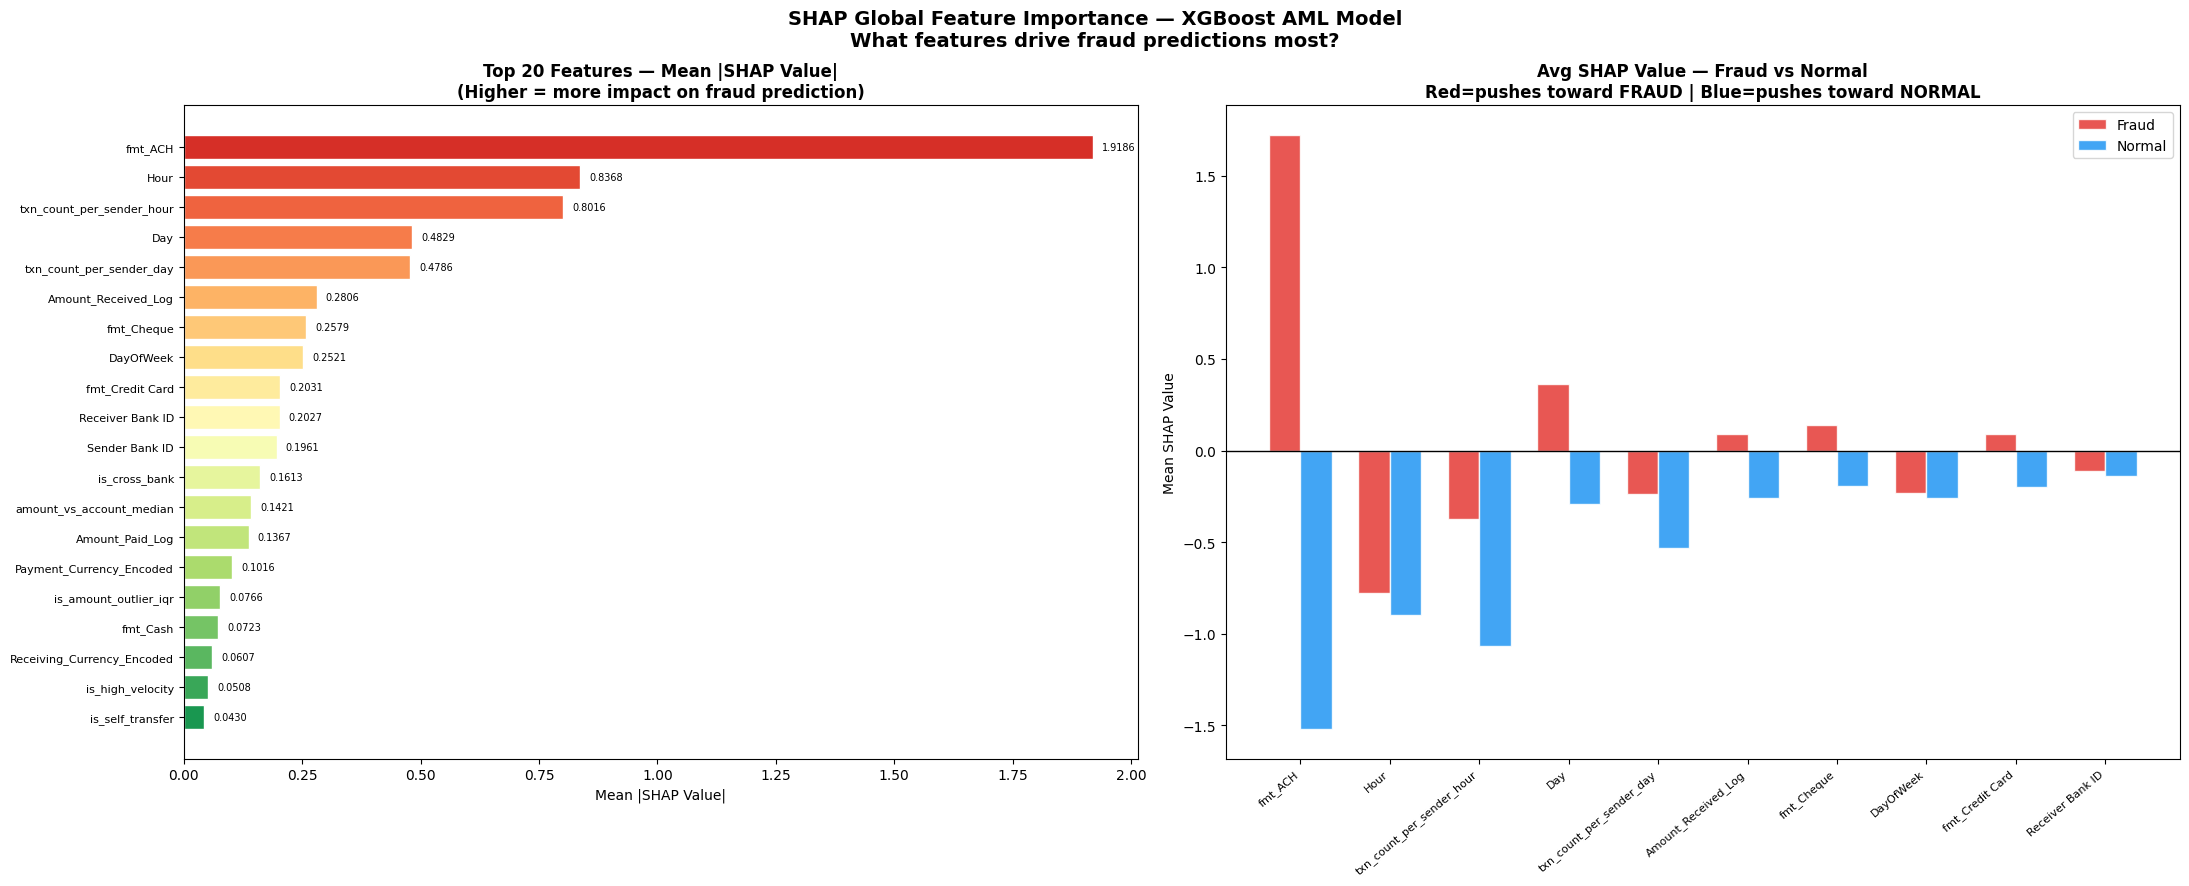

Global importance chart saved!

Top 15 most important features:
                  feature  mean_shap
                  fmt_ACH   1.918606
                     Hour   0.836803
txn_count_per_sender_hour   0.801560
                      Day   0.482875
 txn_count_per_sender_day   0.478594
      Amount_Received_Log   0.280550
               fmt_Cheque   0.257944
                DayOfWeek   0.252117
          fmt_Credit Card   0.203148
         Receiver Bank ID   0.202656
           Sender Bank ID   0.196137
            is_cross_bank   0.161344
 amount_vs_account_median   0.142076
          Amount_Paid_Log   0.136749
 Payment_Currency_Encoded   0.101569


In [35]:
# ── Mean absolute SHAP = global importance ────────────────
mean_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'mean_shap' : mean_shap
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle(
    'SHAP Global Feature Importance — XGBoost AML Model\n'
    'What features drive fraud predictions most?',
    fontsize=14, fontweight='bold'
)

# ── Chart 1: Top 20 bar chart ─────────────────────────────
top20 = importance_df.head(20)
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 20))

axes[0].barh(
    top20['feature'][::-1],
    top20['mean_shap'][::-1],
    color     = colors_bar,
    edgecolor = 'white'
)
axes[0].set_title(
    'Top 20 Features — Mean |SHAP Value|\n'
    '(Higher = more impact on fraud prediction)',
    fontweight='bold'
)
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].tick_params(axis='y', labelsize=8)

# Add value labels
for i, (_, row) in enumerate(top20[::-1].iterrows()):
    axes[0].text(
        row['mean_shap'] + importance_df['mean_shap'].max() * 0.01,
        i,
        f"{row['mean_shap']:.4f}",
        va='center', fontsize=7
    )

# ── Chart 2: Fraud vs Normal SHAP comparison ──────────────
top10_names = top20['feature'].head(10).tolist()
top10_idx   = [FEATURE_COLS.index(f) for f in top10_names]

fraud_mask_s  = y_sample == 1
normal_mask_s = y_sample == 0

fraud_shap_mean  = shap_values[fraud_mask_s][:, top10_idx].mean(axis=0)
normal_shap_mean = shap_values[normal_mask_s][:, top10_idx].mean(axis=0)

x_pos = np.arange(len(top10_names))
w     = 0.35
axes[1].bar(
    x_pos - w/2, fraud_shap_mean,  w,
    label='Fraud',  color='#E53935', edgecolor='white', alpha=0.85
)
axes[1].bar(
    x_pos + w/2, normal_shap_mean, w,
    label='Normal', color='#2196F3', edgecolor='white', alpha=0.85
)
axes[1].set_title(
    'Avg SHAP Value — Fraud vs Normal\n'
    'Red=pushes toward FRAUD | Blue=pushes toward NORMAL',
    fontweight='bold'
)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(top10_names, rotation=40, ha='right', fontsize=8)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].legend()
axes[1].set_ylabel('Mean SHAP Value')

plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Global importance chart saved!")
print(f"\nTop 15 most important features:")
print(importance_df.head(15)[['feature','mean_shap']].to_string(index=False))

## Beeswarm plot

Generating SHAP beeswarm plot...
(Each dot = one transaction, colored by feature value)


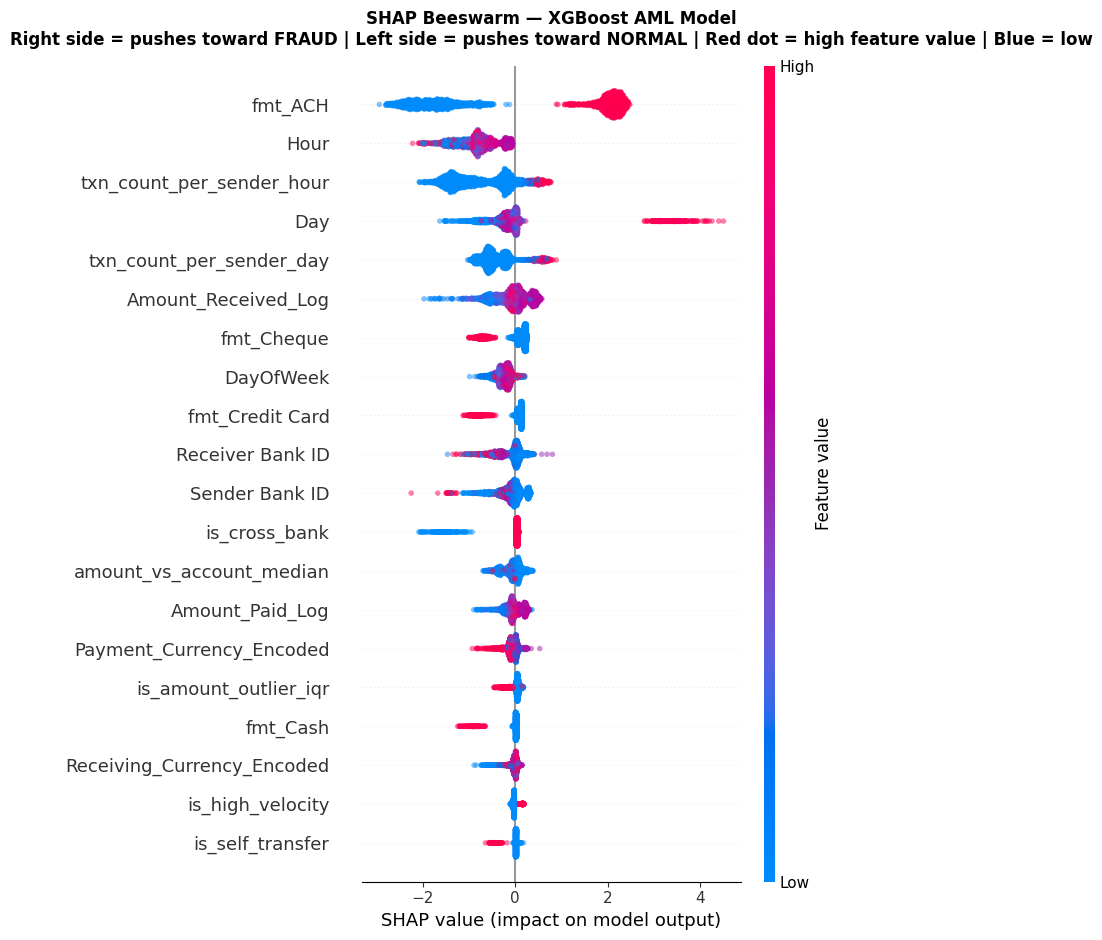

Beeswarm saved!


In [36]:
print("Generating SHAP beeswarm plot...")
print("(Each dot = one transaction, colored by feature value)")

plt.figure(figsize=(13, 11))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names = FEATURE_COLS,
    max_display   = 20,
    plot_type     = 'dot',
    show          = False,
    alpha         = 0.5,
    color_bar     = True
)

plt.title(
    'SHAP Beeswarm — XGBoost AML Model\n'
    'Right side = pushes toward FRAUD | '
    'Left side = pushes toward NORMAL | '
    'Red dot = high feature value | Blue = low',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("Beeswarm saved!")

## Waterfall plots for top fraud transactions

Generating waterfall plots for top 5 highest-risk transactions...
Fraud in sample : 1035
Top 5 risk scores: [np.float32(0.998516), np.float32(0.9974541), np.float32(0.99726737), np.float32(0.99720544), np.float32(0.9971819)]


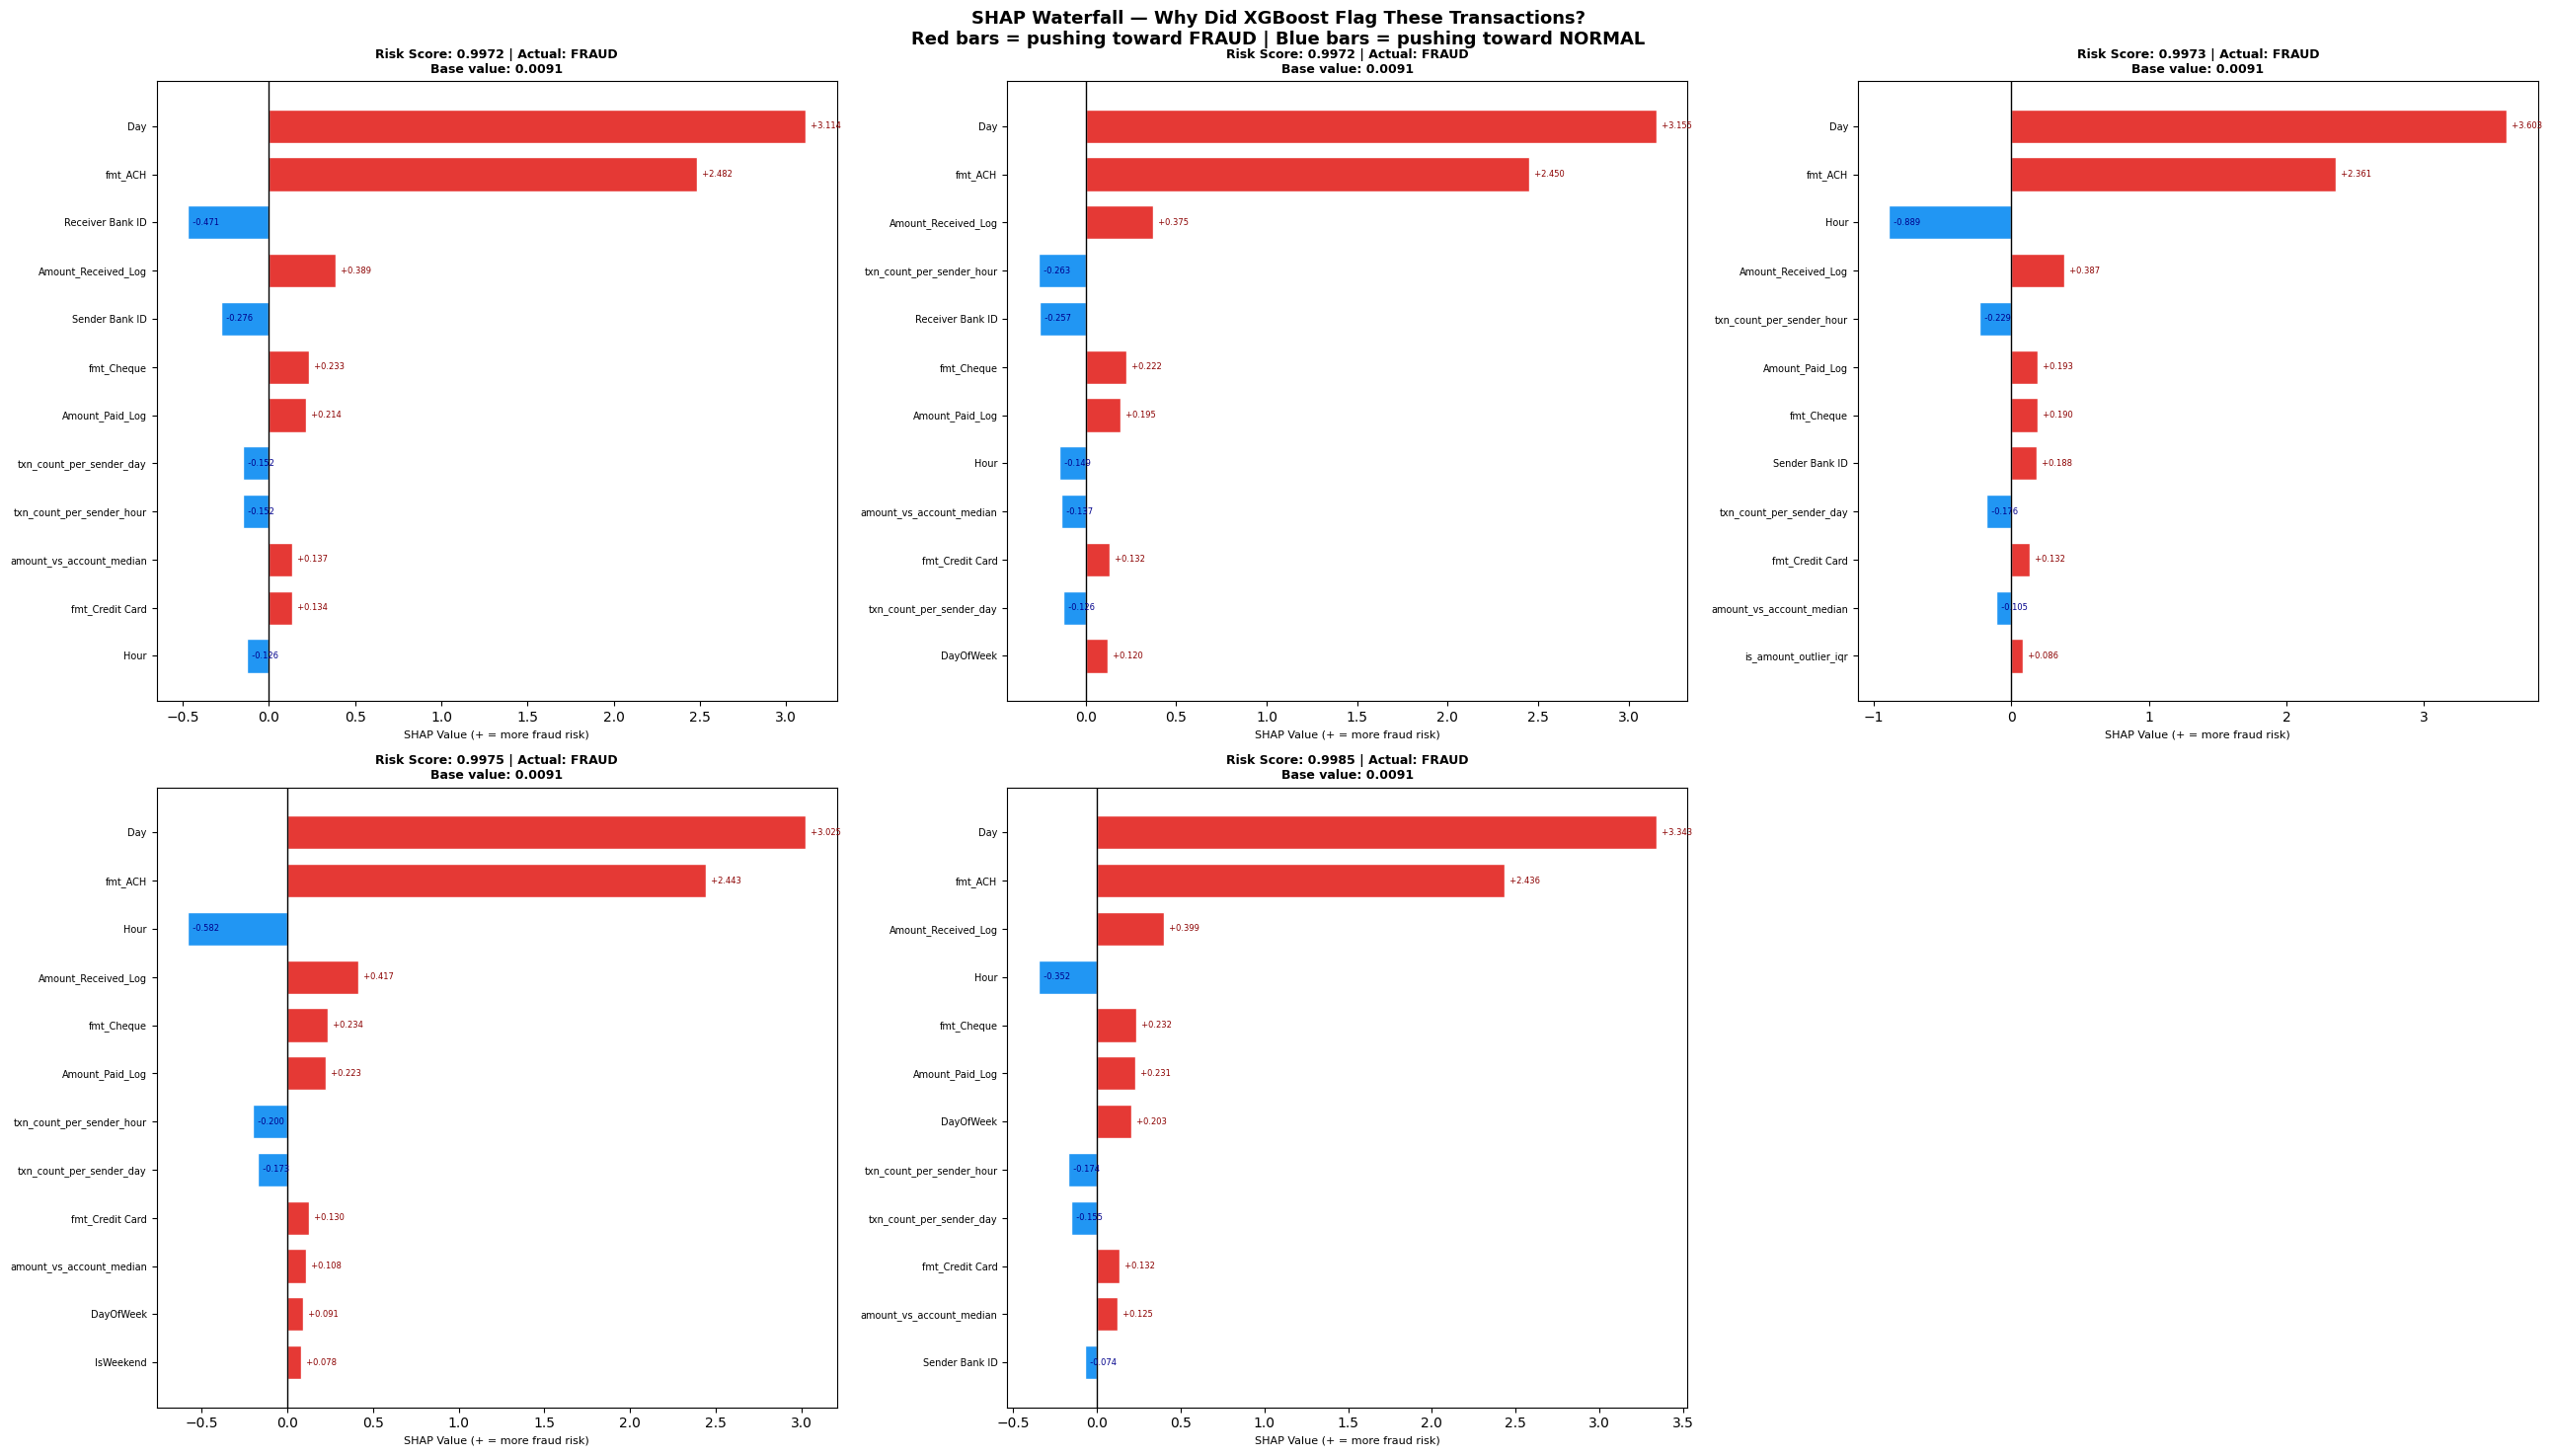

Waterfall plots saved!


In [37]:
# ── Get top 5 highest-risk fraud transactions ─────────────
fraud_in_sample = np.where(y_sample == 1)[0]
fraud_proba_in_sample = proba_sample[fraud_in_sample]
top5_pos = fraud_in_sample[np.argsort(fraud_proba_in_sample)[-5:]]

print(f"Generating waterfall plots for top 5 highest-risk transactions...")
print(f"Fraud in sample : {len(fraud_in_sample)}")
print(f"Top 5 risk scores: {sorted(fraud_proba_in_sample, reverse=True)[:5]}")

fig, axes = plt.subplots(2, 3, figsize=(26, 15))
fig.suptitle(
    'SHAP Waterfall — Why Did XGBoost Flag These Transactions?\n'
    'Red bars = pushing toward FRAUD | Blue bars = pushing toward NORMAL',
    fontsize=13, fontweight='bold'
)
axes_flat = axes.flatten()

for plot_i, local_idx in enumerate(top5_pos):
    txn_shap  = shap_values[local_idx]
    txn_score = proba_sample[local_idx]
    txn_vals  = X_sample.iloc[local_idx].values

    # Sort by absolute SHAP value — most impactful first
    exp_df = pd.DataFrame({
        'feature'    : FEATURE_COLS,
        'shap_value' : txn_shap,
        'feat_value' : txn_vals
    }).sort_values('shap_value', key=abs, ascending=False).head(12)

    bar_colors = [
        '#E53935' if v > 0 else '#2196F3'
        for v in exp_df['shap_value']
    ]

    axes_flat[plot_i].barh(
        exp_df['feature'][::-1],
        exp_df['shap_value'][::-1],
        color     = bar_colors[::-1],
        edgecolor = 'white',
        height    = 0.7
    )
    axes_flat[plot_i].axvline(x=0, color='black', linewidth=1)
    axes_flat[plot_i].set_title(
        f'Risk Score: {txn_score:.4f} | Actual: FRAUD\n'
        f'Base value: {explainer.expected_value:.4f}',
        fontweight='bold', fontsize=9
    )
    axes_flat[plot_i].set_xlabel('SHAP Value (+ = more fraud risk)', fontsize=8)
    axes_flat[plot_i].tick_params(axis='y', labelsize=7)

    # Add value annotations
    for j, (_, row) in enumerate(exp_df[::-1].iterrows()):
        axes_flat[plot_i].text(
            row['shap_value'],
            j,
            f"  {row['shap_value']:+.3f}",
            va='center', fontsize=6,
            color='darkred' if row['shap_value'] > 0 else 'darkblue'
        )

# Hide unused subplot
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plots saved!")

## SHAP dependence plots

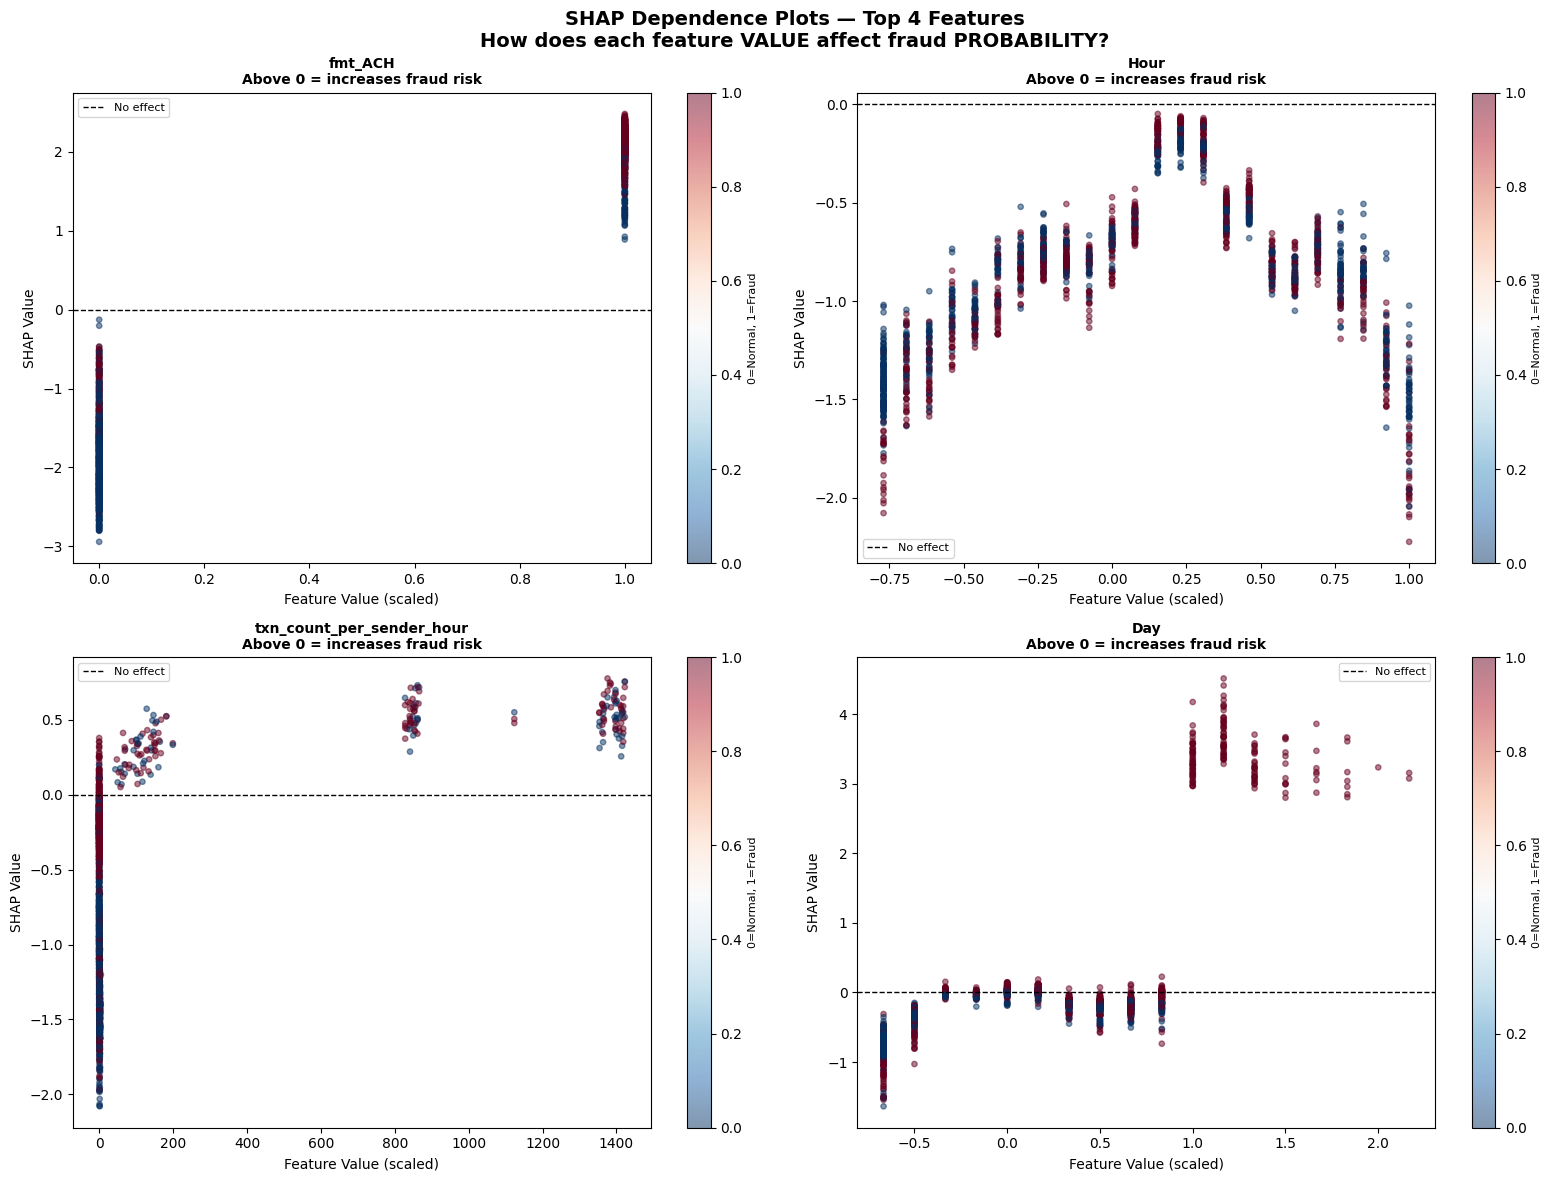

Dependence plots saved!


In [38]:
# ── Top 4 features — how value affects fraud risk ─────────
top4_features = importance_df.head(4)['feature'].tolist()
top4_idx      = [FEATURE_COLS.index(f) for f in top4_features]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'SHAP Dependence Plots — Top 4 Features\n'
    'How does each feature VALUE affect fraud PROBABILITY?',
    fontsize=14, fontweight='bold'
)
axes_flat = axes.flatten()

for i, (feat, fidx) in enumerate(zip(top4_features, top4_idx)):
    feat_vals  = X_sample.iloc[:, fidx].values
    feat_shaps = shap_values[:, fidx]

    sc = axes_flat[i].scatter(
        feat_vals,
        feat_shaps,
        c     = y_sample,
        cmap  = 'RdBu_r',
        alpha = 0.5,
        s     = 15,
        vmin  = 0,
        vmax  = 1
    )
    axes_flat[i].axhline(
        y=0, color='black',
        linewidth=1, linestyle='--',
        label='No effect'
    )
    axes_flat[i].set_title(
        f'{feat}\nAbove 0 = increases fraud risk',
        fontweight='bold', fontsize=10
    )
    axes_flat[i].set_xlabel('Feature Value (scaled)')
    axes_flat[i].set_ylabel('SHAP Value')
    axes_flat[i].legend(fontsize=8)

    cbar = plt.colorbar(sc, ax=axes_flat[i])
    cbar.set_label('0=Normal, 1=Fraud', fontsize=8)

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dependence plots saved!")

## Summary violin/bar plot

SHAP SUMMARY BAR ANALYSIS

Checking SHAP data...
X_sample shape : (2000, 30)
SHAP values shape : (2000, 30)
Number of features : 30

SHAP values converted to NumPy array.
Using 2-dimensional SHAP values. Shape: (2000, 30)

Feature dimensions match successfully!

Top 15 SHAP Features:
                  feature  mean_shap
                  fmt_ACH   1.918606
                     Hour   0.836803
txn_count_per_sender_hour   0.801560
                      Day   0.482875
 txn_count_per_sender_day   0.478594
      Amount_Received_Log   0.280550
               fmt_Cheque   0.257944
                DayOfWeek   0.252117
          fmt_Credit Card   0.203148
         Receiver Bank ID   0.202656
           Sender Bank ID   0.196137
            is_cross_bank   0.161344
 amount_vs_account_median   0.142076
          Amount_Paid_Log   0.136749
 Payment_Currency_Encoded   0.101569

Creating SHAP summary bar plot...


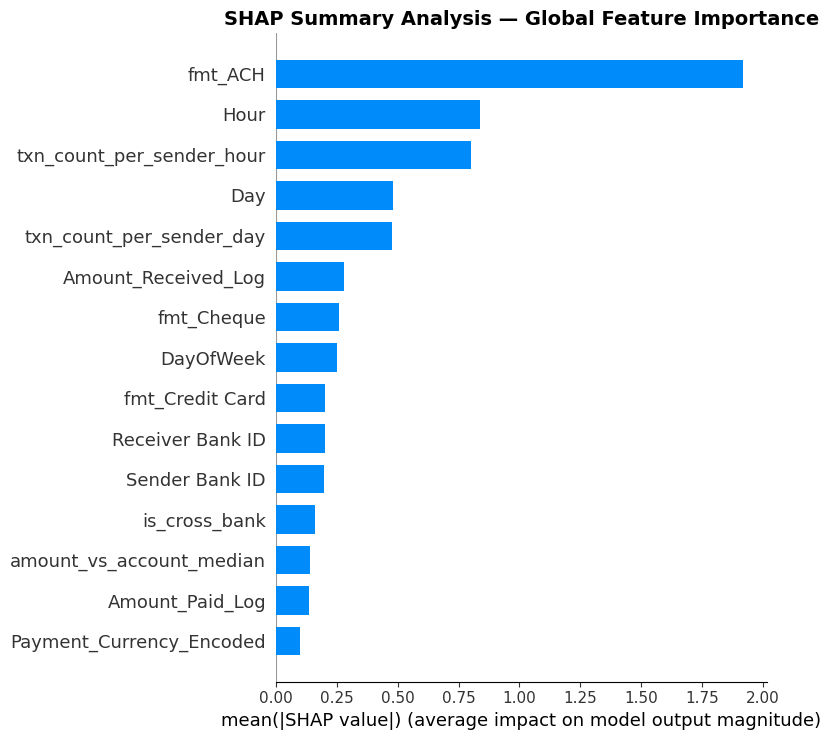

SHAP built-in bar chart saved!

Creating custom SHAP importance chart...


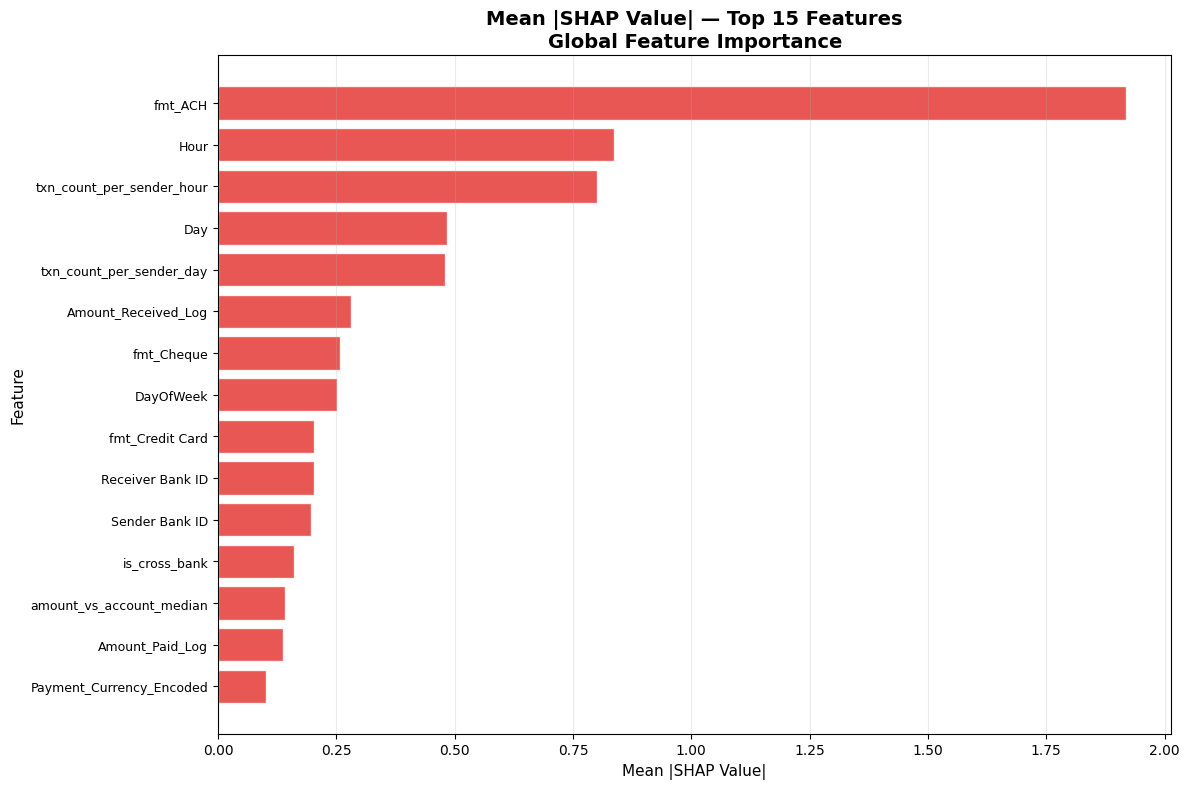


SUMMARY BAR CHARTS SAVED SUCCESSFULLY

Files created:
1. shap_summary_bar_shap.png
2. shap_bar_summary.png


In [40]:
# ============================================================
# SHAP SUMMARY BAR ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("=" * 60)
print("SHAP SUMMARY BAR ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Basic validation
# ------------------------------------------------------------

print("\nChecking SHAP data...")

print(f"X_sample shape : {X_sample.shape}")
print(f"SHAP values shape : {np.asarray(shap_values).shape}")
print(f"Number of features : {len(FEATURE_COLS)}")

# ------------------------------------------------------------
# 2. Convert SHAP values safely to NumPy array
# ------------------------------------------------------------

shap_values_array = np.asarray(shap_values)

print("\nSHAP values converted to NumPy array.")

# ------------------------------------------------------------
# 3. Handle possible multi-output SHAP format
# ------------------------------------------------------------

if shap_values_array.ndim == 3:

    print(
        "Detected 3-dimensional SHAP values "
        "(multi-output classification format)."
    )

    print(f"Original shape: {shap_values_array.shape}")

    # For binary classification, use fraud class (class 1)
    shap_values_plot = shap_values_array[:, :, 1]

    print(
        f"Using fraud class (class 1). "
        f"New shape: {shap_values_plot.shape}"
    )

elif shap_values_array.ndim == 2:

    shap_values_plot = shap_values_array

    print(
        f"Using 2-dimensional SHAP values. "
        f"Shape: {shap_values_plot.shape}"
    )

else:

    raise ValueError(
        f"Unexpected SHAP values dimensions: "
        f"{shap_values_array.ndim}"
    )

# ------------------------------------------------------------
# 4. Verify feature dimensions
# ------------------------------------------------------------

if shap_values_plot.shape[1] != len(FEATURE_COLS):

    raise ValueError(
        f"Feature mismatch!\n"
        f"SHAP values have {shap_values_plot.shape[1]} features, "
        f"but FEATURE_COLS contains {len(FEATURE_COLS)} features."
    )

print("\nFeature dimensions match successfully!")

# ------------------------------------------------------------
# 5. Calculate global SHAP importance
# ------------------------------------------------------------

mean_abs_shap = np.mean(
    np.abs(shap_values_plot),
    axis=0
)

importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mean_shap": mean_abs_shap
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    "mean_shap",
    ascending=False
).reset_index(drop=True)

print("\nTop 15 SHAP Features:")
print(importance_df.head(15).to_string(index=False))

# ------------------------------------------------------------
# 6. SHAP built-in bar summary plot
# ------------------------------------------------------------

print("\nCreating SHAP summary bar plot...")

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_plot,
    X_sample,
    feature_names=FEATURE_COLS,
    max_display=15,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Summary Analysis — Global Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "shap_summary_bar_shap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("SHAP built-in bar chart saved!")

# ------------------------------------------------------------
# 7. Custom clean horizontal bar chart
# ------------------------------------------------------------

print("\nCreating custom SHAP importance chart...")

top15 = importance_df.head(15).copy()

plt.figure(figsize=(12, 8))

plt.barh(
    top15["feature"][::-1],
    top15["mean_shap"][::-1],
    color="#E53935",
    edgecolor="white",
    alpha=0.85
)

plt.title(
    "Mean |SHAP Value| — Top 15 Features\n"
    "Global Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Mean |SHAP Value|",
    fontsize=11
)

plt.ylabel(
    "Feature",
    fontsize=11
)

plt.tick_params(
    axis="y",
    labelsize=9
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "shap_bar_summary.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 60)
print("SUMMARY BAR CHARTS SAVED SUCCESSFULLY")
print("=" * 60)

print("\nFiles created:")
print("1. shap_summary_bar_shap.png")
print("2. shap_bar_summary.png")

## Auto SAR narrative generation

In [45]:
def generate_sar_narrative(local_idx, X_sample, proba_sample,
                            shap_values, FEATURE_COLS,
                            explainer, top_n=5):
    """
    Auto-generate SAR narrative for one flagged transaction.
    Uses SHAP values to explain why it was flagged.
    """
    txn_score = proba_sample[local_idx]
    txn_shap  = shap_values[local_idx]
    txn_vals  = X_sample.iloc[local_idx]

    # Sort by SHAP value
    exp_df = pd.DataFrame({
        'feature'    : FEATURE_COLS,
        'shap_value' : txn_shap,
        'feat_value' : txn_vals.values
    }).sort_values('shap_value', ascending=False)

    top_risk     = exp_df[exp_df['shap_value'] > 0].head(top_n)
    top_mitigate = exp_df[exp_df['shap_value'] < 0].head(3)

    if txn_score >= 0.8:   level = 'CRITICAL'
    elif txn_score >= 0.6: level = 'HIGH'
    elif txn_score >= 0.4: level = 'MEDIUM'
    else:                  level = 'LOW'

    lines = [
        f"\n{'═'*62}",
        f"  SUSPICIOUS ACTIVITY REPORT — AUTO DRAFT",
        f"  Generated by: FinShield AI v1.0",
        f"{'═'*62}",
        f"  RISK SCORE   : {txn_score:.4f} / 1.0000",
        f"  RISK LEVEL   : {level}",
        f"  BASE VALUE   : {explainer.expected_value:.6f}",
        f"  NET PUSH     : +{txn_score - explainer.expected_value:.4f} toward fraud",
        f"{'─'*62}",
        f"  PRIMARY RISK FACTORS (pushing toward FRAUD):",
    ]

    for _, row in top_risk.iterrows():
        lines.append(
            f"    ► {row['feature']:<40} "
            f"SHAP: +{row['shap_value']:.4f}"
        )

    lines += [
        f"\n  MITIGATING FACTORS (pushing toward NORMAL):",
    ]
    for _, row in top_mitigate.iterrows():
        lines.append(
            f"    ▼ {row['feature']:<40} "
            f"SHAP: {row['shap_value']:.4f}"
        )

    lines += [
        f"\n{'─'*62}",
        f"  DECISION      : ESCALATE FOR ANALYST REVIEW",
        f"  STATUS        : PENDING",
        f"{'═'*62}",
    ]

    return '\n'.join(lines)


# Generate SAR for top 3 fraud transactions
print("Auto-generated SAR Narratives:\n")
for rank, idx in enumerate(top5_pos[-3:], 1):
    print(f"SAR #{rank} (Rank {rank} highest risk fraud):")
    print(generate_sar_narrative(
        idx, X_sample, proba_sample,
        shap_values, FEATURE_COLS, explainer
    ))
    print()

Auto-generated SAR Narratives:

SAR #1 (Rank 1 highest risk fraud):

══════════════════════════════════════════════════════════════
  SUSPICIOUS ACTIVITY REPORT — AUTO DRAFT
  Generated by: FinShield AI v1.0
══════════════════════════════════════════════════════════════
  RISK SCORE   : 0.9973 / 1.0000
  RISK LEVEL   : CRITICAL
  BASE VALUE   : 0.009053
  NET PUSH     : +0.9882 toward fraud
──────────────────────────────────────────────────────────────
  PRIMARY RISK FACTORS (pushing toward FRAUD):
    ► Day                                      SHAP: +3.6026
    ► fmt_ACH                                  SHAP: +2.3608
    ► Amount_Received_Log                      SHAP: +0.3871
    ► Amount_Paid_Log                          SHAP: +0.1925
    ► fmt_Cheque                               SHAP: +0.1901

  MITIGATING FACTORS (pushing toward NORMAL):
    ▼ is_amount_outlier_zscore                 SHAP: -0.0000
    ▼ IsWeekend                                SHAP: -0.0003
    ▼ fmt_Reinvestment

## Save all SHAP results

In [46]:
os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

# ── Save SHAP values ───────────────────────────────────────
shap_df = pd.DataFrame(
    shap_values,
    columns = [f'shap_{f}' for f in FEATURE_COLS]
)
shap_df['actual_label']    = y_sample
shap_df['predicted_proba'] = proba_sample
shap_df.to_csv('results/shap_values.csv', index=False)
print(f"Saved: results/shap_values.csv ({len(shap_df):,} rows)")

# ── Save feature importance ────────────────────────────────
importance_df.to_csv(
    'results/shap_feature_importance.csv', index=False
)
print(f"Saved: results/shap_feature_importance.csv")

# ── Save explainer ────────────────────────────────────────
import pickle
with open('models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)
print(f"Saved: models/shap_explainer.pkl")

print(f"\nAll SHAP files saved!")
print(f"\nTop 10 most important features:")
print(importance_df.head(10)[['feature','mean_shap']].to_string(index=False))

Saved: results/shap_values.csv (2,000 rows)
Saved: results/shap_feature_importance.csv
Saved: models/shap_explainer.pkl

All SHAP files saved!

Top 10 most important features:
                  feature  mean_shap
                  fmt_ACH   1.918606
                     Hour   0.836803
txn_count_per_sender_hour   0.801560
                      Day   0.482875
 txn_count_per_sender_day   0.478594
      Amount_Received_Log   0.280550
               fmt_Cheque   0.257944
                DayOfWeek   0.252117
          fmt_Credit Card   0.203148
         Receiver Bank ID   0.202656


## Final summary

In [47]:
print("=" * 60)
print("SHAP EXPLAINABILITY — COMPLETE")
print("=" * 60)

print(f"""
WHAT WAS DONE
  Model         : XGBoost (AUC-ROC {auc_roc:.4f})
  Features      : {len(FEATURE_COLS)}
  Explainer     : SHAP TreeExplainer (exact — not approximation)
  Base value    : {explainer.expected_value:.6f}
  Sample size   : {len(X_sample):,} transactions
  Fraud in sample: {y_sample.sum():,}

TOP 5 FRAUD SIGNALS (by SHAP importance)
{chr(10).join(f"  {i+1}. {row['feature']:<40} {row['mean_shap']:.4f}"
              for i, row in importance_df.head(5).iterrows())}

CHARTS SAVED
  shap_global_importance.png  ← feature importance bar
  shap_beeswarm.png           ← all transactions scatter
  shap_waterfall.png          ← individual explanations
  shap_dependence.png         ← feature vs fraud push
  shap_bar_summary.png        ← clean summary bar

FILES SAVED
  results/shap_values.csv
  results/shap_feature_importance.csv
  models/shap_explainer.pkl

NEXT → Notebook 13: Risk Scoring Engine
""")

SHAP EXPLAINABILITY — COMPLETE

WHAT WAS DONE
  Model         : XGBoost (AUC-ROC 0.9732)
  Features      : 30
  Explainer     : SHAP TreeExplainer (exact — not approximation)
  Base value    : 0.009053
  Sample size   : 2,000 transactions
  Fraud in sample: 1,035

TOP 5 FRAUD SIGNALS (by SHAP importance)
  1. fmt_ACH                                  1.9186
  2. Hour                                     0.8368
  3. txn_count_per_sender_hour                0.8016
  4. Day                                      0.4829
  5. txn_count_per_sender_day                 0.4786

CHARTS SAVED
  shap_global_importance.png  ← feature importance bar
  shap_beeswarm.png           ← all transactions scatter
  shap_waterfall.png          ← individual explanations
  shap_dependence.png         ← feature vs fraud push
  shap_bar_summary.png        ← clean summary bar

FILES SAVED
  results/shap_values.csv
  results/shap_feature_importance.csv
  models/shap_explainer.pkl

NEXT → Notebook 13: Risk Scoring Engi